# Mesh Area Comparison · 3 Inference Results

对比每位 volunteer 的 10 组测试结果。每位 volunteer 生成一张独立柱状图，横坐标为 Test 1–10；每个测试点有三根并列柱，分别来自：

- PyTorch · 2048 × 2448：`result/pytorch_2048x2448/areas.json`
- TensorRT · 800 × 960 · attention-axis-fixed：`result/tensorrt_800x960_attention_axis_fixed/areas.json`
- TensorRT · 800 × 960 · GWC Plugin V3：`result/tensorrt_800x960_gwc_plugin/areas.json`

图使用 `areas.json` 的 `areas_m2` 字段，转换为 cm² 后显示；每根柱上方标出取整后的面积值。四张图分别保存为 `docs/assets/mesh_area_comparison_<volunteer>.png`。

In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / 'result').is_dir() and (candidate / 'FoundationStereo').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError('Open this notebook from the FS_Engine repository or python/ directory.')
REPO_ROOT = REPO_ROOT.resolve()

SOURCES = (
    ('PyTorch · 2048×2448', 'pytorch_2048x2448/areas.json', '#2563eb'),
    ('TensorRT · 800×960 · attention-axis-fixed',
     'tensorrt_800x960_attention_axis_fixed/areas.json', '#f97316'),
    ('TensorRT · 800×960 · GWC Plugin V3',
     'tensorrt_800x960_gwc_plugin/areas.json', '#16a34a'),
)
VOLUNTEERS = ('Volunteer2_lower', 'Volunteer2_upper', 'Volunteer3_lower', 'Volunteer3_upper')
CAPTURES = tuple(str(index) for index in range(10))
OUTPUT_DIR = REPO_ROOT / 'docs' / 'assets'

def load_area_result(relative_path: str) -> dict:
    path = REPO_ROOT / 'result' / relative_path
    if not path.is_file():
        raise FileNotFoundError(f'Missing comparison input: {path}')
    payload = json.loads(path.read_text(encoding='utf-8'))
    if payload.get('unit') != 'm²' or not isinstance(payload.get('areas_m2'), dict):
        raise ValueError(f'Unexpected areas.json format: {path}')
    return payload['areas_m2']

AREA_RESULTS = {label: load_area_result(relative_path) for label, relative_path, _ in SOURCES}

for label, areas_by_volunteer in AREA_RESULTS.items():
    for volunteer in VOLUNTEERS:
        if volunteer not in areas_by_volunteer:
            raise KeyError(f'{label} is missing {volunteer}')
        missing_captures = [capture for capture in CAPTURES if capture not in areas_by_volunteer[volunteer]]
        if missing_captures:
            raise KeyError(f'{label} / {volunteer} is missing captures: {missing_captures}')

print('Comparison inputs:')
for label, relative_path, _ in SOURCES:
    print(f' - {label}: result/{relative_path}')


Comparison inputs:
 - PyTorch · 2048×2448: result/pytorch_2048x2448/areas.json
 - TensorRT · 800×960 · attention-axis-fixed: result/tensorrt_800x960_attention_axis_fixed/areas.json
 - TensorRT · 800×960 · GWC Plugin V3: result/tensorrt_800x960_gwc_plugin/areas.json


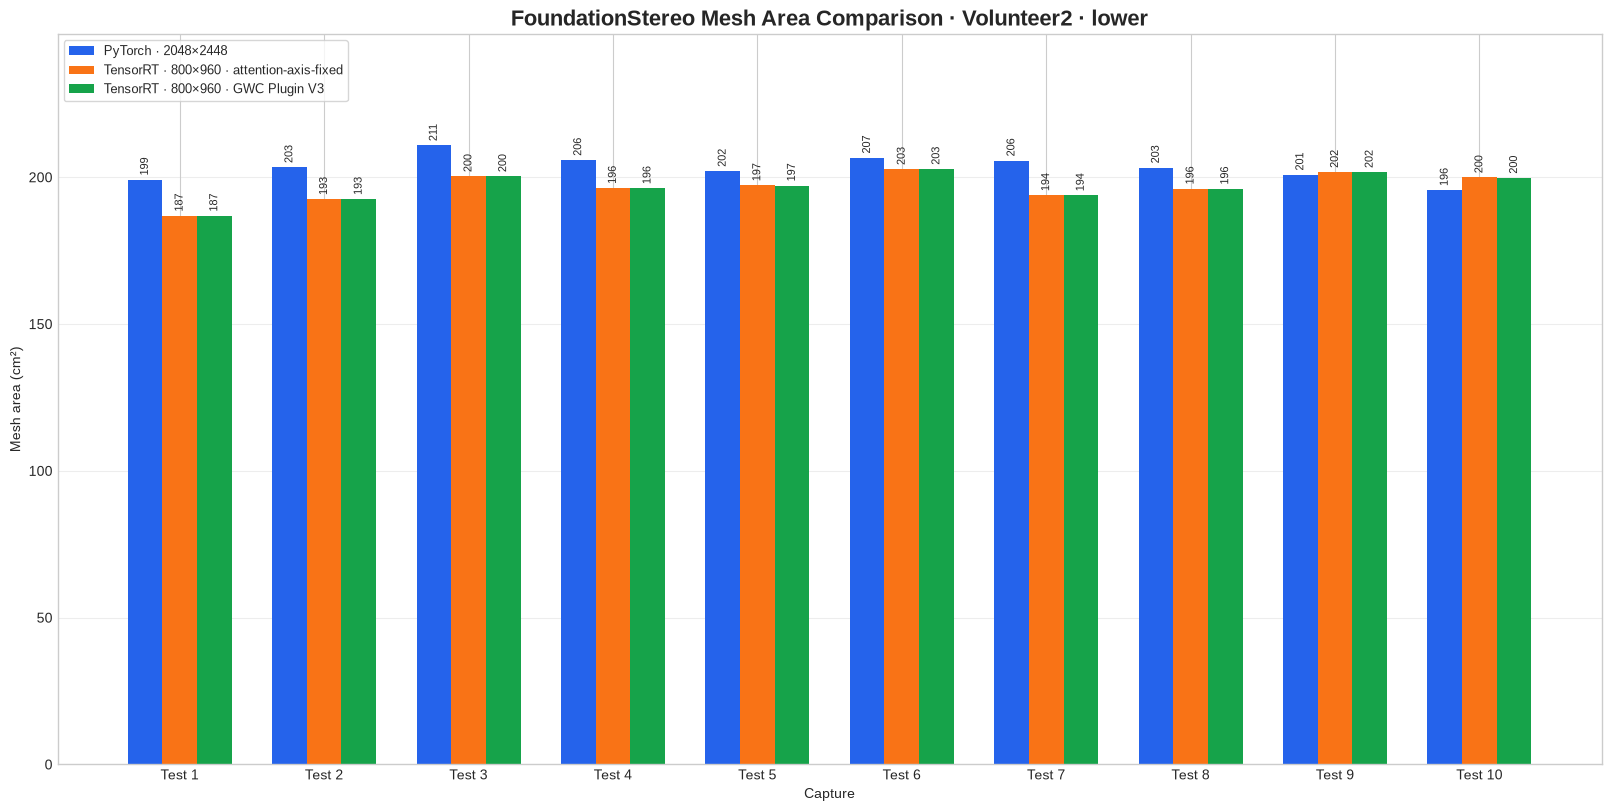

Saved: /home/liu4000/Desktop/FS_Engine/docs/assets/mesh_area_comparison_volunteer2_lower.png


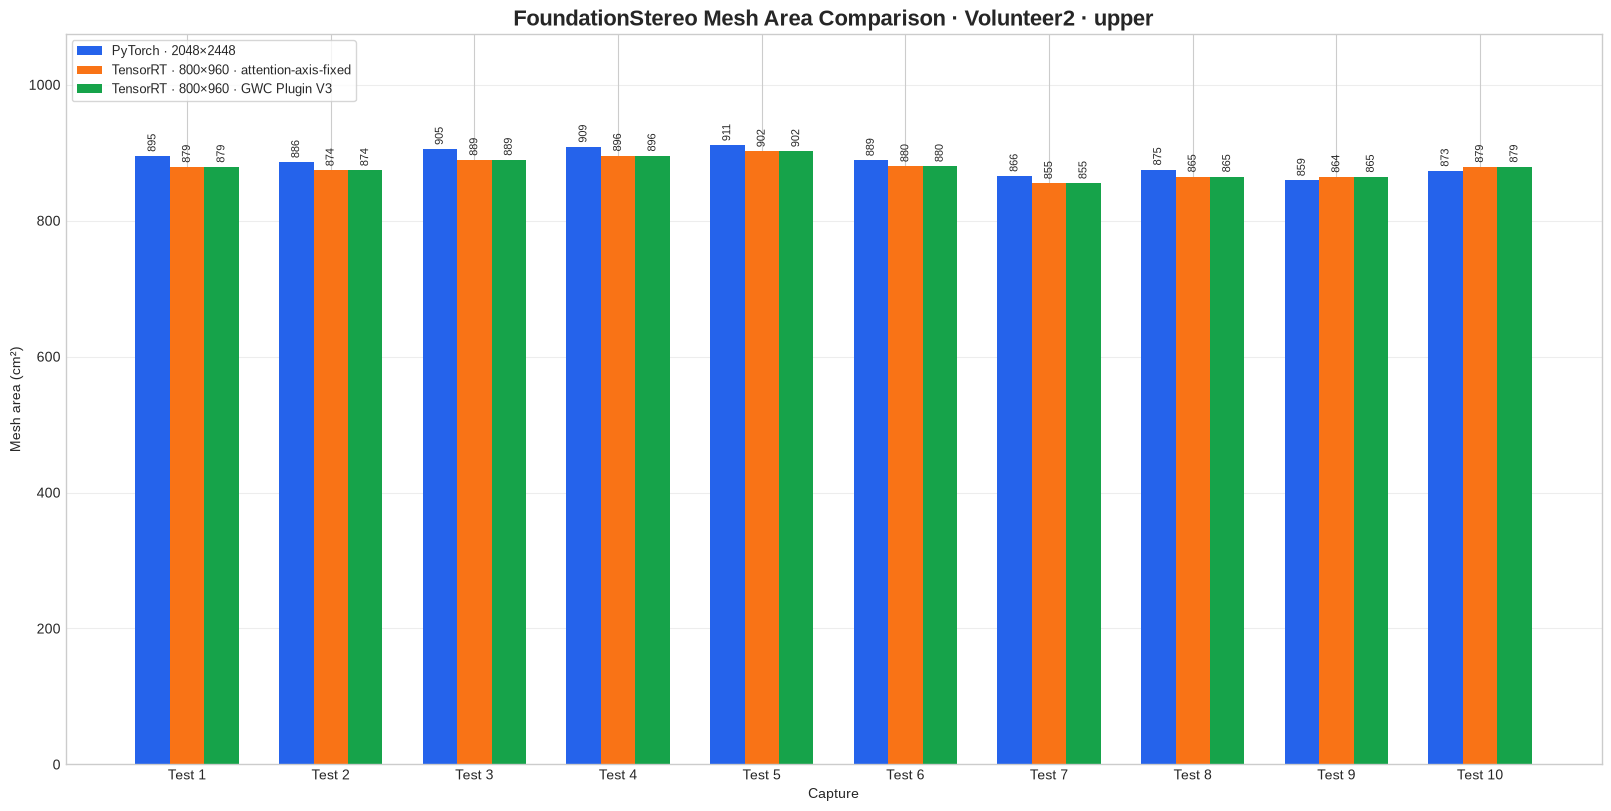

Saved: /home/liu4000/Desktop/FS_Engine/docs/assets/mesh_area_comparison_volunteer2_upper.png


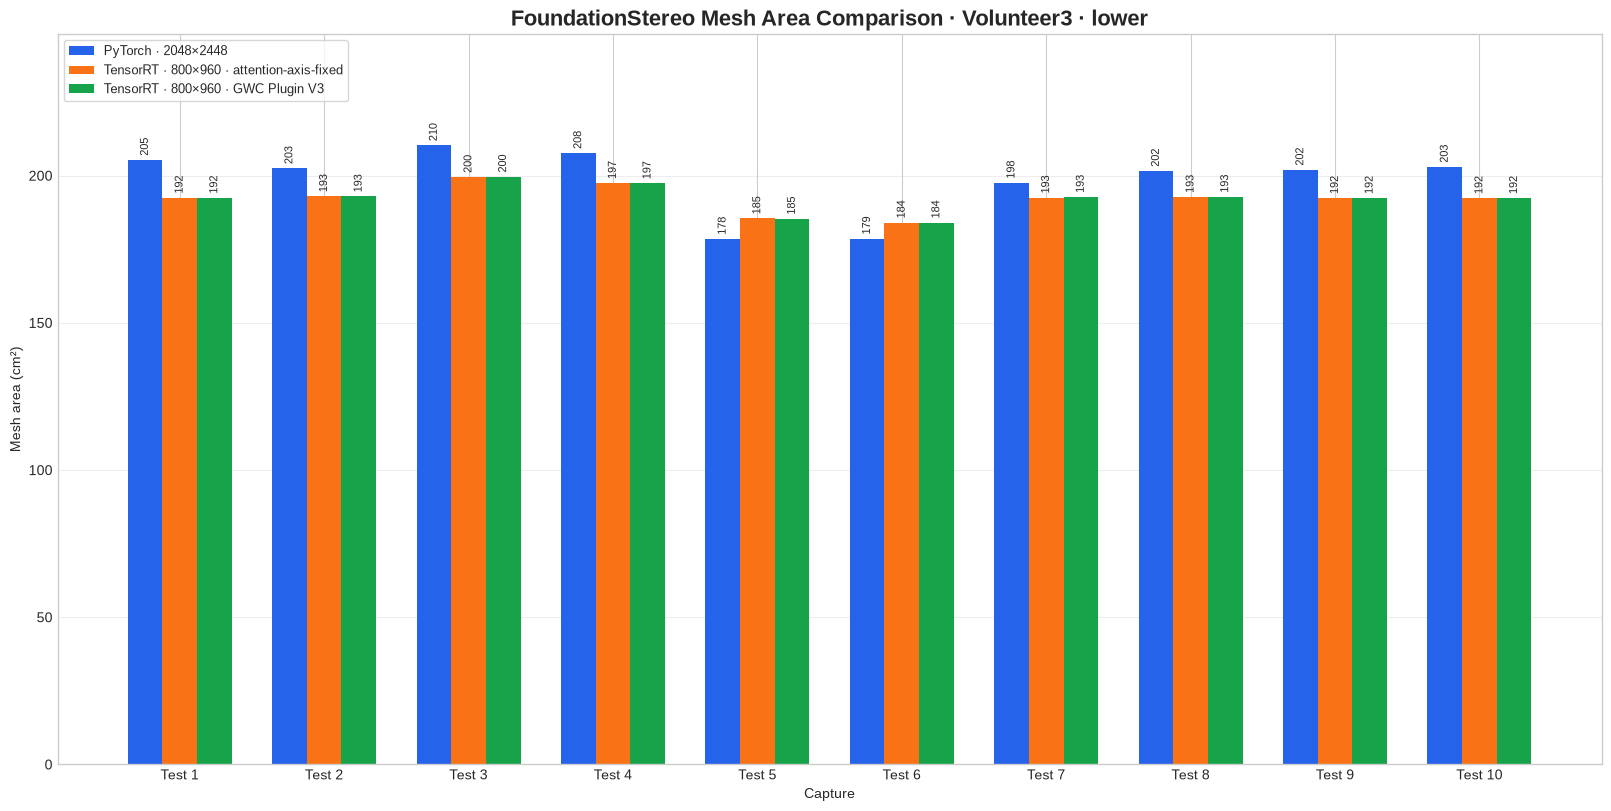

Saved: /home/liu4000/Desktop/FS_Engine/docs/assets/mesh_area_comparison_volunteer3_lower.png


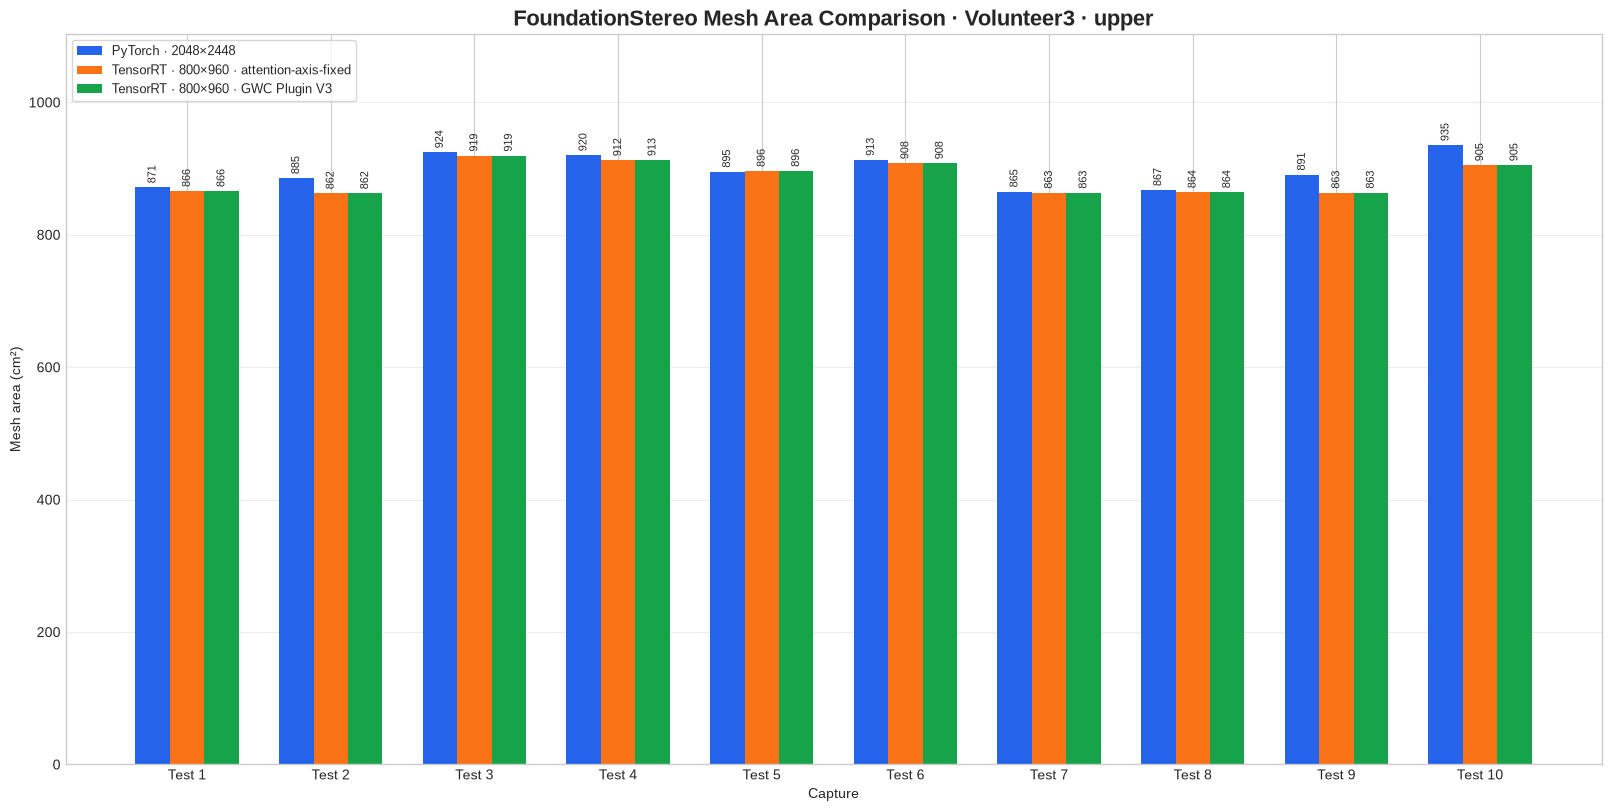

Saved: /home/liu4000/Desktop/FS_Engine/docs/assets/mesh_area_comparison_volunteer3_upper.png


In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
positions = np.arange(1, len(CAPTURES) + 1)
bar_width = 0.24
offsets = (-bar_width, 0.0, bar_width)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for volunteer in VOLUNTEERS:
    figure, axis = plt.subplots(figsize=(16, 8), constrained_layout=True)
    max_area_cm2 = 0.0
    for (label, _, color), offset in zip(SOURCES, offsets):
        areas_m2 = np.asarray([AREA_RESULTS[label][volunteer][capture] for capture in CAPTURES])
        areas_cm2 = areas_m2 * 10_000.0
        max_area_cm2 = max(max_area_cm2, float(areas_cm2.max()))
        bars = axis.bar(positions + offset, areas_cm2, width=bar_width, color=color, label=label)
        axis.bar_label(bars, labels=[f'{area:.0f}' for area in areas_cm2], padding=3, fontsize=8, rotation=90)

    axis.set_title(f'FoundationStereo Mesh Area Comparison · {volunteer.replace("_", " · ")}', fontsize=16, fontweight='bold')
    axis.set_xticks(positions, [f'Test {index}' for index in positions])
    axis.set_xlabel('Capture')
    axis.set_ylabel('Mesh area (cm²)')
    axis.tick_params(axis='x', rotation=0)
    axis.grid(axis='y', alpha=0.35)
    axis.set_ylim(0, max_area_cm2 * 1.18)
    axis.legend(loc='upper left', frameon=True, fontsize=9)

    output_path = OUTPUT_DIR / f'mesh_area_comparison_{volunteer.lower()}.png'
    figure.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(figure)
    print(f'Saved: {output_path}')
